In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('../data/monthly_features.csv')

# Features used for training
FEATURE_COLS = [
    'Year', 'Month', 'Month_sin', 'Month_cos', 'Quarter',
    'Sales_Lag1', 'Sales_Lag2', 'Sales_Lag3', 'Sales_Roll3',
    'Total_Qty', 'Avg_Discount', 'Order_Count'
]

TARGET = 'Total_Sales'

X = df[FEATURE_COLS]
y = df[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (45, 12)
y shape: (45,)


In [3]:
# For time series — do NOT shuffle! Keep chronological order
split_idx = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

Training samples : 36
Testing samples  : 9


In [4]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("✅ Random Forest trained!")

✅ Random Forest trained!


In [5]:
def evaluate(model, X_test, y_test, name="Model"):
    preds = model.predict(X_test)
    mae   = mean_absolute_error(y_test, preds)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    r2    = r2_score(y_test, preds)
    print(f"\n📊 {name} Results")
    print(f"   MAE  : ${mae:,.2f}")
    print(f"   RMSE : ${rmse:,.2f}")
    print(f"   R²   : {r2:.4f}")
    return preds

rf_preds = evaluate(rf_model, X_test, y_test, "Random Forest")


📊 Random Forest Results
   MAE  : $10,763.05
   RMSE : $14,775.66
   R²   : 0.6495


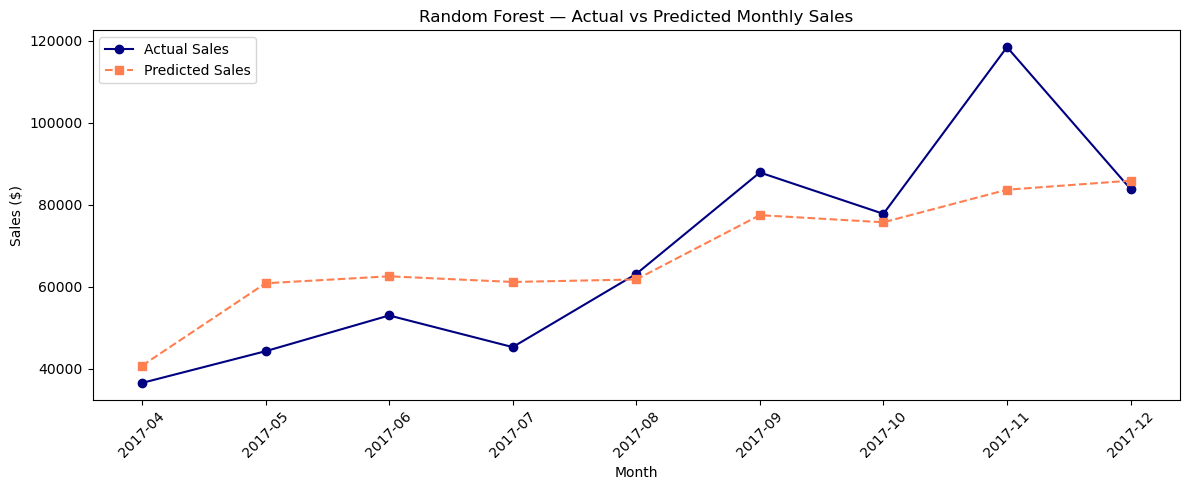

✅ Chart saved!


In [6]:
test_dates = df.iloc[split_idx:][['Year','Month']].copy()
test_dates['Label'] = test_dates['Year'].astype(str) + '-' + test_dates['Month'].astype(str).str.zfill(2)

plt.figure(figsize=(12,5))
plt.plot(test_dates['Label'], y_test.values,  label='Actual Sales',    color='navy',  marker='o')
plt.plot(test_dates['Label'], rf_preds,        label='Predicted Sales', color='coral', marker='s', linestyle='--')
plt.title('Random Forest — Actual vs Predicted Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/actual_vs_predicted.png', dpi=150)
plt.show()
print("✅ Chart saved!")

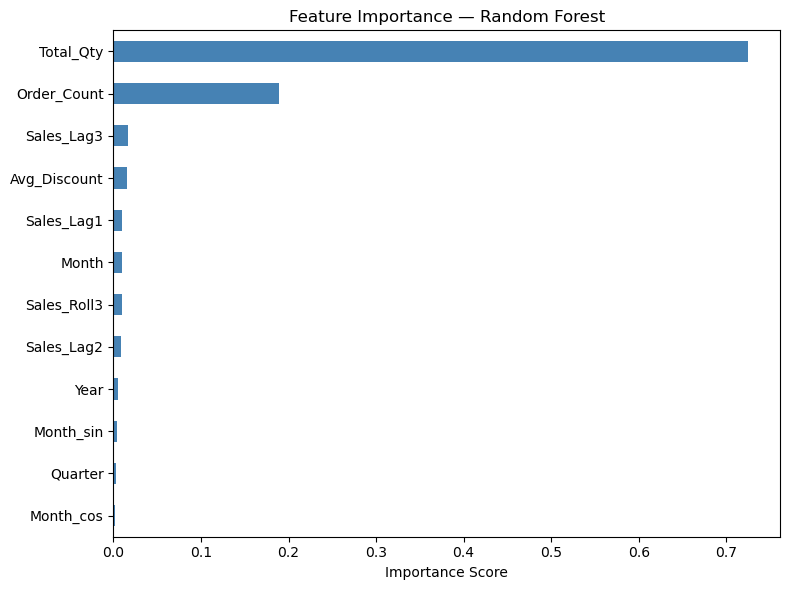

In [7]:
feat_imp = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

plt.figure(figsize=(8,6))
feat_imp.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=150)
plt.show()

In [8]:
joblib.dump(rf_model, '../models/rf_sales_model.pkl')
joblib.dump(FEATURE_COLS, '../models/feature_cols.pkl')
print("✅ Model saved!")

✅ Model saved!
